In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn import GaussianFourierEmbedding
from probjax.nn.nets.flow_matching_model import LinearMeanFlow

import importlib 


importlib.import_module("examples.nn.examples")
from examples.nn.examples import CheckerboardGenerator, SpiralGenerator, CrescentGenerator







In [3]:
gen = CheckerboardGenerator()
data = gen.generate(1000000, jax.random.PRNGKey(0))


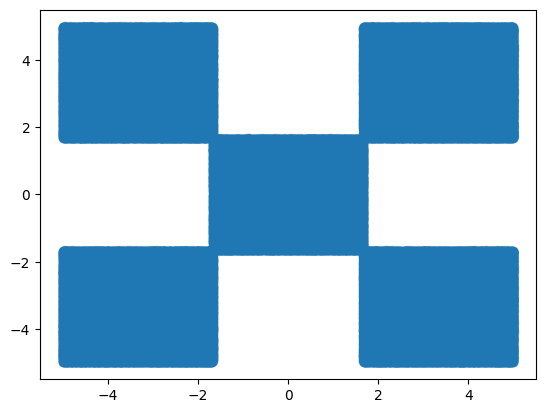

In [4]:
plt.scatter(data[:,0], data[:,1], alpha=0.1)

In [ ]:
from probjax.nn.nets.simple import ResNet, MLP


class BaseModel(nnx.Module, experimental_pytree=True):
    def __init__(self, d, rngs, time_embed_dim=64, hidden_dim=256) -> None:
        self.time_embedding1 = GaussianFourierEmbedding(1,time_embed_dim, rngs=rngs)
        self.time_embedding2 = GaussianFourierEmbedding(1,time_embed_dim, rngs=rngs)
        self.time_mlp = MLP([time_embed_dim*2, time_embed_dim, time_embed_dim], rngs=rngs)
        self.resnet = ResNet(d,hidden_dim,rngs,context_dim=time_embed_dim, num_hidden_layers=5, norm=nnx.LayerNorm, hidden_dim=hidden_dim)
        self.out1 = nnx.Linear(hidden_dim,d, rngs=rngs, kernel_init=nnx.initializers.zeros)
    def __call__(self, t,x, r=None, *args, **kwargs):
        r_embed = self.time_embedding1(t-r)
        t_embed = self.time_embedding2(t)
        rt_embed = self.time_mlp(jnp.concatenate([r_embed, t_embed], axis=-1))
        h = self.resnet(x, context=rt_embed)
        h = jax.nn.gelu(h)
        v = self.out1(h)

        return v

net = BaseModel(2, nnx.Rngs(0))
model = LinearMeanFlow(net,std0=1., std1=data.std(0))
params = nnx.state(model, nnx.Param)

In [58]:

import optax

def loss_fn(params, rng, x):
    nnx.update(model, params)
    return model.loss(rng, x)

@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng,x)
    updates, opt_state = opt.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

In [72]:
import optax

scheduler = optax.cosine_onecycle_schedule(40000, 1e-4)
opt = optax.chain(optax.adaptive_grad_clip(1.), optax.adam(scheduler))
opt_state = opt.init(params)


In [73]:
key = jax.random.key(42)

In [74]:
losses = []
for i in range(400):
    l = 0.
    for j in range(100):
        key,key_data, key_loss = jax.random.split(key, 3)
        #xs = jax.vmap(generate_data)(jax.random.split(key_data, 1000))
        xs = jax.random.choice(key_data, data, (10_000,), axis=0)
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    losses.append(l/100)

In [75]:
nnx.update(model, params)

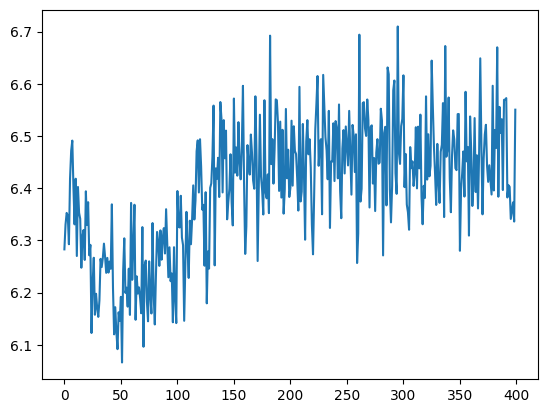

In [76]:
# Its actually good if the loss goes up here xD Thats due to the stop_gradient i.e. its more like a fixed point iteration.

plt.plot(losses)

In [77]:
nnx.update(model, params)

In [78]:
d = 2
def sample(rng, numsteps=5):
    xt = jax.random.normal(rng, (d,))
    ts = jnp.linspace(0, 1, numsteps + 1)
    for i in range(numsteps):
        t = ts[i]
        r = ts[i + 1]
        print(t,r)
        u = model(jnp.array([t]), xt, r=jnp.array([r]))
        xt = xt + u * (r-t)
    return xt

In [83]:
from functools import partial
samples = jax.vmap(partial(sample, numsteps=20))(jax.random.split(jax.random.PRNGKey(0), 40000))

0.0 0.05
0.05 0.1
0.1 0.15
0.15 0.2
0.2 0.25
0.25 0.3
0.3 0.35
0.35 0.4
0.4 0.45000002
0.45000002 0.5
0.5 0.55
0.55 0.6
0.6 0.65000004
0.65000004 0.7
0.7 0.75
0.75 0.8
0.8 0.85
0.85 0.90000004
0.90000004 0.95
0.95 1.0


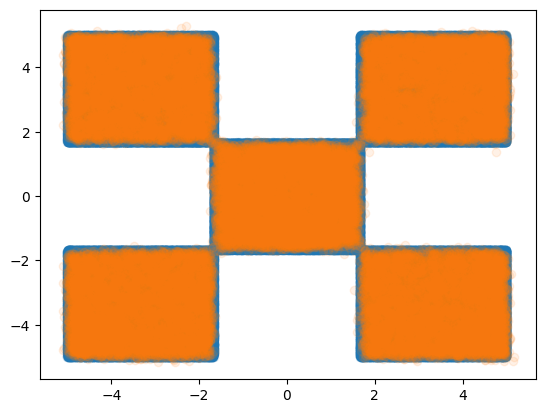

In [84]:
plt.scatter(data[:,0], data[:,1], alpha=0.1)
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)

In [116]:
gen = SpiralGenerator()
data = gen.generate(10000, jax.random.PRNGKey(0))

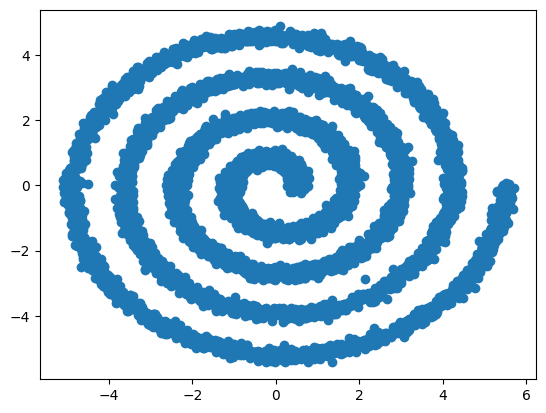

In [117]:
plt.scatter(data[:,0], data[:,1])

In [119]:

net = BaseModel(2, nnx.Rngs(0))
model = LinearMeanFlow(net,std0=1., std1=data.std(0))
params = nnx.state(model, nnx.Param)

scheduler = optax.cosine_onecycle_schedule(40000, 1e-4)
opt = optax.chain(optax.adaptive_grad_clip(1.), optax.adam(scheduler))
opt_state = opt.init(params)


In [ ]:
losses = []
for i in range(400):
    l = 0.
    for j in range(100):
        key,key_data, key_loss = jax.random.split(key, 3)
        #xs = jax.vmap(generate_data)(jax.random.split(key_data, 1000))
        xs = jax.random.choice(key_data, data, (5_000,), axis=0)
        params, opt_state, loss = update(params, opt_state, xs,key_loss)
        l += loss
    losses.append(l/100)

2025-08-01 15:15:11.789498: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2025-08-01 15:15:11.789543: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


In [121]:
nnx.update(model, params)

0.0 0.25
0.25 0.5
0.5 0.75
0.75 1.0


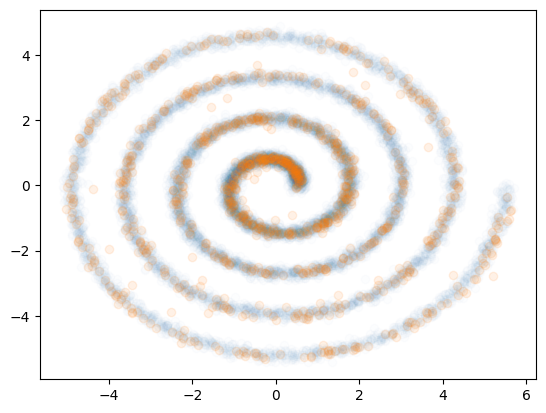

In [126]:
from functools import partial
samples = jax.vmap(partial(sample, numsteps=4))(jax.random.split(jax.random.PRNGKey(0), 1000))
plt.scatter(data[:,0], data[:,1], alpha=0.01)
plt.scatter(samples[:,0], samples[:,1], alpha=0.1)